In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 改造ChannelAttention，返回注意力权重
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x : (B,C,H,W)
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        out = avg_out + max_out
        attention = self.sigmoid(out)  # (B, C, 1, 1) 注意力权重
        return x * attention, attention  # 同时返回加权后的特征和注意力权重

# 改造SimpleCNN，保存注意力权重
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=16, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.ca = ChannelAttention(channels=64)  # 通道注意力模块
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv5 = nn.Conv2d(in_channels=64, out_channels=3, kernel_size=3, stride=1, padding=1)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x, attention = self.ca(x)  # 提取注意力权重
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.conv5(x)
        return x, attention  # 返回输出和注意力权重

In [3]:
# 设备设置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 加载高维表征
tensor_path = 'rendering.pt'
test_input = torch.load(tensor_path).unsqueeze(0).to(device)  # (1,16,64,64)
print(f"输入张量形状: {test_input.shape}")

# 定义两个解码器（场景解码器+隐写解码器）
# 场景解码器（加载场景任务的权重）
scene_cnn = SimpleCNN().to(device)
scene_cnn.load_state_dict(torch.load('/home/qhuang/GS-Hider/output/room_kitchen_attention_5w/chkpnt50000_net.pth'))
scene_cnn.eval()

# 隐写解码器（加载隐写任务的权重）
stego_cnn = SimpleCNN().to(device)
stego_cnn.load_state_dict(torch.load('/home/qhuang/GS-Hider/output/room_kitchen_attention_5w/chkpnt50000_waternet.pth'))
stego_cnn.eval()

# 提取注意力权重（推理模式，禁用梯度）
with torch.no_grad():
    _, scene_attention = scene_cnn(test_input)  # 场景解码器的注意力权重 (1,64,1,1)
    _, stego_attention = stego_cnn(test_input)  # 隐写解码器的注意力权重 (1,64,1,1)

# 处理权重：从GPU转CPU，压缩维度
scene_att_weights = scene_attention.squeeze().cpu().numpy()  # (64,)
stego_att_weights = stego_attention.squeeze().cpu().numpy()  # (64,)

# 可选：加载无注意力的模型（对比组）
class SimpleCNN_NoAttention(nn.Module):
    def __init__(self):
        super(SimpleCNN_NoAttention, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=16, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv5 = nn.Conv2d(in_channels=64, out_channels=3, kernel_size=3, stride=1, padding=1)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.conv5(x)
        return x

# 无注意力模型加载（可选）
no_att_cnn = SimpleCNN_NoAttention().to(device)
no_att_cnn.load_state_dict(torch.load('output/room_kitchen_5w/chkpnt50000_net.pth'))
no_att_cnn.eval()

输入张量形状: torch.Size([1, 16, 519, 778])


SimpleCNN_NoAttention(
  (conv1): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

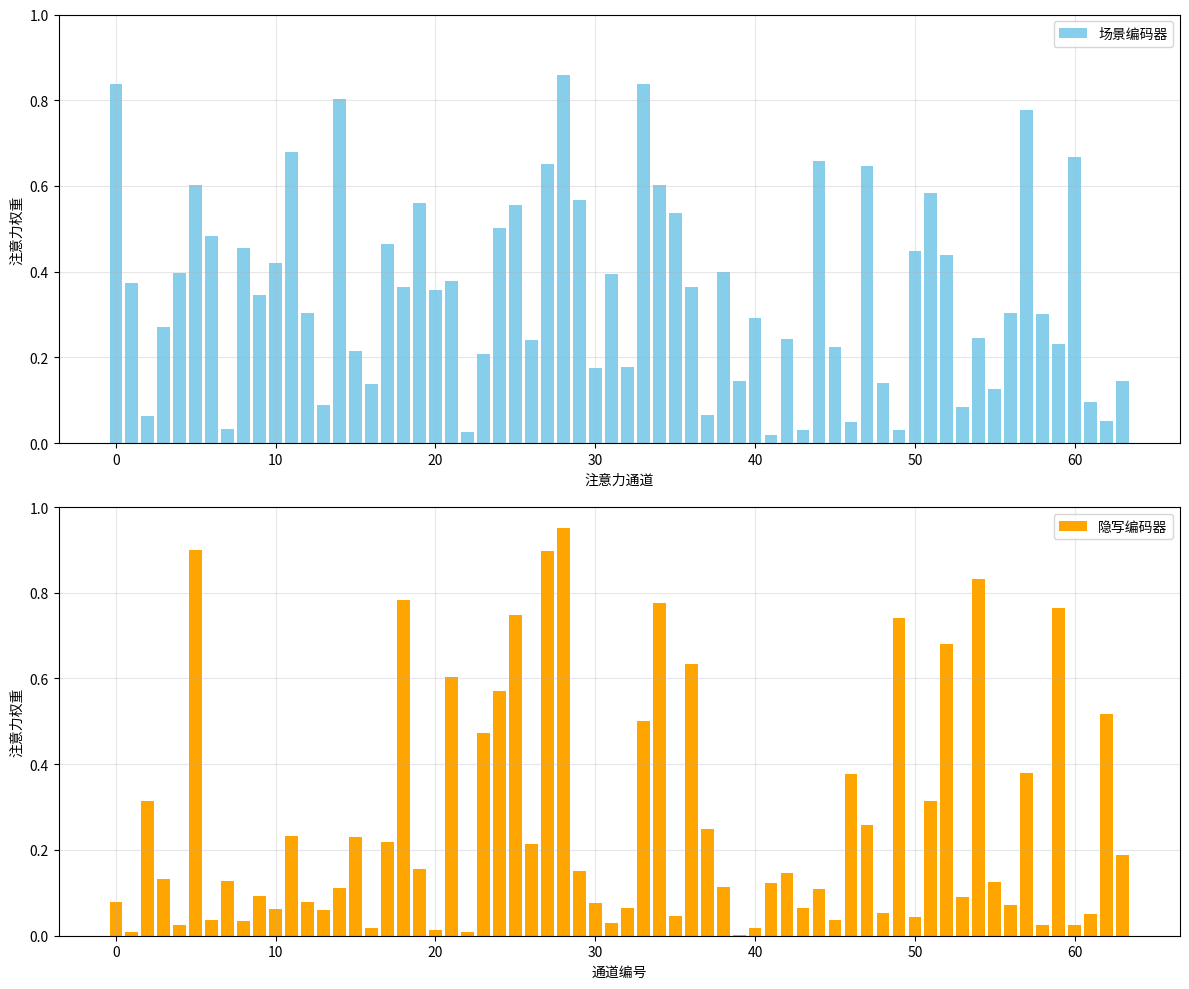

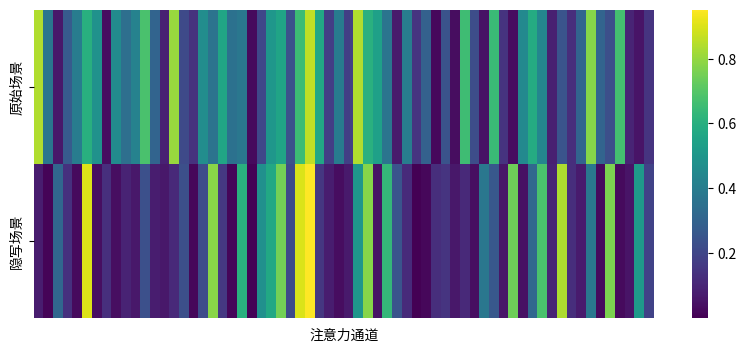

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
font_path = "result/NotoSansCJK-Regular.otf"
# 注册字体
font_manager.fontManager.addfont(font_path)
# 获取字体名字（很关键）
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
# 设置全局字体
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 图1：通道权重分布对比（柱状图）
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12, 10))
# 场景解码器通道权重
ax1.bar(range(64), scene_att_weights, color='skyblue', label='场景编码器')
# ax1.set_title('Channel Attention Weights - Scene Decoder', fontweight='bold')
ax1.set_xlabel('注意力通道')
ax1.set_ylabel('注意力权重')
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(alpha=0.3)

# 隐写解码器通道权重
ax2.bar(range(64), stego_att_weights, color='orange', label='隐写编码器')
# ax2.set_title('Channel Attention Weights - Stego Decoder', fontweight='bold')
ax2.set_xlabel('通道编号')
ax2.set_ylabel('注意力权重')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('result/channel_attention_weights.pdf', dpi=300, bbox_inches='tight')
plt.show()

# 图2：权重热力图（对比两个解码器）
fig, ax = plt.subplots(figsize=(10, 4))
# 构建对比矩阵 (2,64)
att_matrix = np.vstack([scene_att_weights, stego_att_weights])
# 热力图
sns.heatmap(att_matrix, cmap='viridis', ax=ax, 
            # xticklabels=range(1,65), yticklabels=['原始场景', '隐写场景'])
            xticklabels=False, yticklabels=['原始场景', '隐写场景'])
# ax.set_title('Channel Attention Weight Heatmap (Scene vs Stego)', fontweight='bold')
ax.set_xlabel('注意力通道')
# ax.set_ylabel('解码器类型')
plt.savefig('result/attention_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()

# # 图3：权重分布统计（箱线图，对比有/无注意力）
# # 可选：如果有“无注意力”模型的特征，可对比特征方差（无注意力则特征分布更均匀）
# scene_att_mean = np.mean(scene_att_weights)
# stego_att_mean = np.mean(stego_att_weights)
# scene_att_std = np.std(scene_att_weights)
# stego_att_std = np.std(stego_att_weights)

# # 打印关键统计值（论文可用）
# print(f"场景解码器注意力权重 - 均值: {scene_att_mean:.4f}, 标准差: {scene_att_std:.4f}")
# print(f"隐写解码器注意力权重 - 均值: {stego_att_mean:.4f}, 标准差: {stego_att_std:.4f}")

# # 箱线图
# fig, ax = plt.subplots(figsize=(8, 6))
# box_data = [scene_att_weights, stego_att_weights]
# ax.boxplot(box_data, labels=['场景解码器', '隐写解码器'])
# # ax.set_title('Attention Weight Distribution', fontweight='bold')
# ax.set_ylabel('注意力权重')
# ax.grid(alpha=0.3)
# plt.savefig('result/attention_boxplot.pdf', dpi=300, bbox_inches='tight')
# plt.show()

选中的通道: [2, 47, 4, 39]
✅ 单通道已保存到：single_channels/


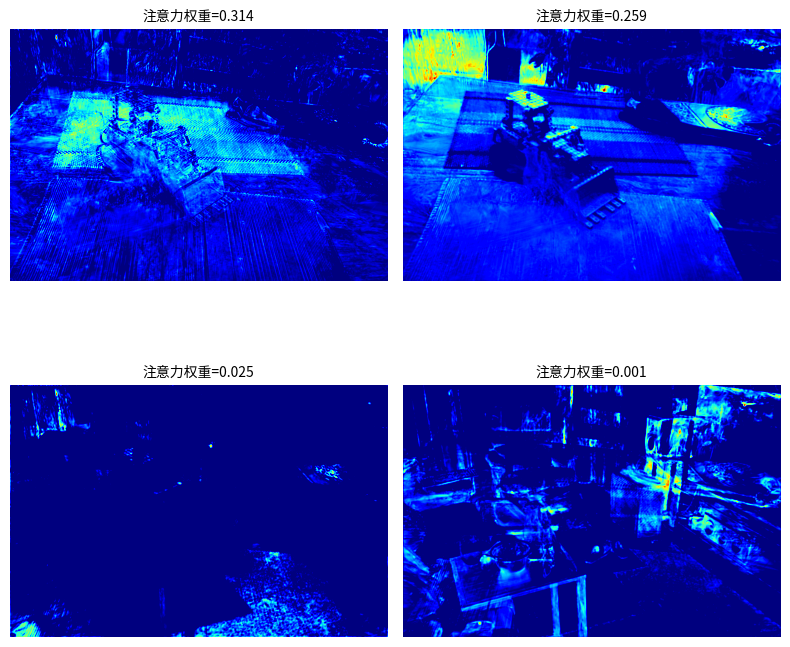

✅ 拼接图已保存：stego_attention.pdf


In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
import os

def visualize_selected_channels(model, input_tensor, channel_ids, 
                                save_path='spatial_attention_4ch.pdf',
                                single_dir='result/single_channels'):
    """
    channel_ids: list，比如 [3, 7, 15, 42]
    single_dir: 单张图保存目录
    """

    assert len(channel_ids) == 4, "必须提供4个通道ID，例如 [0,1,2,3]"

    # ✅ 创建保存目录
    os.makedirs(single_dir, exist_ok=True)

    model.eval()
    with torch.no_grad():
        x = F.relu(model.conv1(input_tensor))
        weighted_x, attention = model.ca(x)

        feat_maps = weighted_x.squeeze(0).cpu().numpy()   # (C,H,W)
        att_weights = attention.squeeze().cpu().numpy()   # (C,)

    print("选中的通道:", channel_ids)

    # =========================
    # ✅ 1️⃣ 单独保存每个通道
    # =========================
    for ch in channel_ids:
        fm = feat_maps[ch]
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)

        plt.figure(figsize=(3, 3))
        plt.imshow(fm, cmap='jet')
        # plt.title(f'注意力权重={att_weights[ch]:.3f}', fontsize=10)
        plt.axis('off')

        single_path = os.path.join(single_dir, f'ch_{ch}.pdf')

        plt.savefig(single_path, dpi=300, bbox_inches='tight')
        plt.close()

    print(f"✅ 单通道已保存到：{single_dir}/")

    # =========================
    # ✅ 2️⃣ 保存拼接图（2x2）
    # =========================
    plt.figure(figsize=(8, 8))

    for i, ch in enumerate(channel_ids):
        ax = plt.subplot(2, 2, i + 1)

        fm = feat_maps[ch]
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)

        ax.imshow(fm, cmap='jet')
        ax.set_title(f'注意力权重={att_weights[ch]:.3f}', fontsize=10)
        ax.axis('off')

    plt.tight_layout()

    # pdf 推荐设置
    plt.rcParams['ps.fonttype'] = 42
    plt.rcParams['axes.unicode_minus'] = False

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ 拼接图已保存：{save_path}")


visualize_selected_channels(
    stego_cnn,
    test_input,
    [2, 47, 4, 39],
    save_path='result/stego_attention.pdf'
)